# COF-Landscaper local workflow

In [1]:
import coflandscaper as cl

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


### Setup

`MODE` accepts `"serr"`, `"incl"`, or `"both"`. Use a distinct `COF_NAME` for each calculation.

Provide topology-appropriate `.xyz` building blocks in `0_node/` and `0_linker/`. Each intended connection site must be marked with `He`.

In [2]:
TOPOLOGY = "hcb"
COF_NAME = "COF-LZU-1"
MODE = "both"

### Single-Layer COF Construction & Pre-Optimization

This step generates the single-layer COF structure and performs MACE pre-optimization.

> **Practical note:** If the input building-block fragments are strongly non-planar, the generated stacking matrix can contain strained or sterically congested geometries. Starting from relatively planar building units is therefore recommended, followed by relaxation of the assembled framework. Because the isolated single-layer model has more conformational freedom than the final stacked COF, the preoptimized layer may twist more strongly than the corresponding bulk structure.

In [ ]:
builder = cl.BuildCOF2D()
builder.build(topo=TOPOLOGY, cof_name=COF_NAME)

In [ ]:
preopt = cl.MaceOpt()
preopt.run_preopt(cof_name=COF_NAME)

### ILD × ILS Structure Matrix Generation

This step generates stacked COF structures by systematically varying:

- **Interlayer Distance (ILD)** (default range: 3.0-4.0 A in steps of 0.1 A)  
- **Interlayer Slipping (ILS)** (default range: 0.0 A to the topology-specific default/max ILS shift in steps of 1.0 A)  
  The serrated endpoint is AB; the inclined endpoint is AB for `sql` and ABC for `hcb`/`kgm`.
  Default ILS shift length and angle are auto-computed from the topology; use `print_shift=True` to display them.

The input structure is the pre-optimized single-layer (AA stacking with large interlayer distance).  
This step converts it into physically meaningful bulk stacking configurations.

Generated stacked structures organized by mode:  
- `.../serr/` → serrated stacking configurations  
- `.../incl/` → inclined stacking configurations  

These structures are intended for subsequent single-point energy evaluations and energy landscape analysis.


In [3]:
matrix = cl.CreateMatrix(print_shift=True)
matrix.run(cof_name=COF_NAME, topo=TOPOLOGY, mode=MODE)

[DEFAULT_SHIFT_VALUES] Length=12.93Å Angle=90.00
[DEFAULT_SHIFT_VALUES] Length=12.93Å Angle=90.00


### MACE Single-Point Energy Evaluation

This step computes single-point energies for generated structures using `MaceSP` (no geometry optimization).

Single-point energies are written ro `{COF_NAME}_sp_energies_{serr|incl}.csv` in `COF_NAME/3_{COF_NAME}_landscape/`  

In [4]:
sp = cl.MaceSP()
sp.run(cof_name=COF_NAME, mode=MODE)

[single-point] 25/154 done | ok=25 | failed=0
[single-point] 50/154 done | ok=50 | failed=0
[single-point] 75/154 done | ok=75 | failed=0
[single-point] 100/154 done | ok=100 | failed=0
[single-point] 125/154 done | ok=125 | failed=0
[single-point] 150/154 done | ok=150 | failed=0
[single-point] 154/154 done | ok=154 | failed=0
[single-point] 25/154 done | ok=25 | failed=0
[single-point] 50/154 done | ok=50 | failed=0
[single-point] 75/154 done | ok=75 | failed=0
[single-point] 100/154 done | ok=100 | failed=0
[single-point] 125/154 done | ok=125 | failed=0
[single-point] 150/154 done | ok=150 | failed=0
[single-point] 154/154 done | ok=154 | failed=0


### Potential Energy Landscape (PES)

This step plots an approximate stacking potential energy surface by mapping the relative energies of the generated ILD/ILS structure matrix as a function of interlayer distance (ILD) and interlayer slipping (ILS).

Because no full structural relaxation is performed at this stage, the PES is treated as a reduced-dimensional screening model rather than a full description of the underlying high-dimensional energy landscape. Within this approximation, it provides a qualitative to semi-quantitative representation of the relative stability of different stacking arrangements and serves to identify candidate minima for subsequent refinement by full geometry optimization.

---

- `show` *(bool, optional, default: `False`)*  
  If `True`, displays interactive plot windows.  

- PES plots `pes_{COF_NAME}_{serr|incl}.png` default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/`

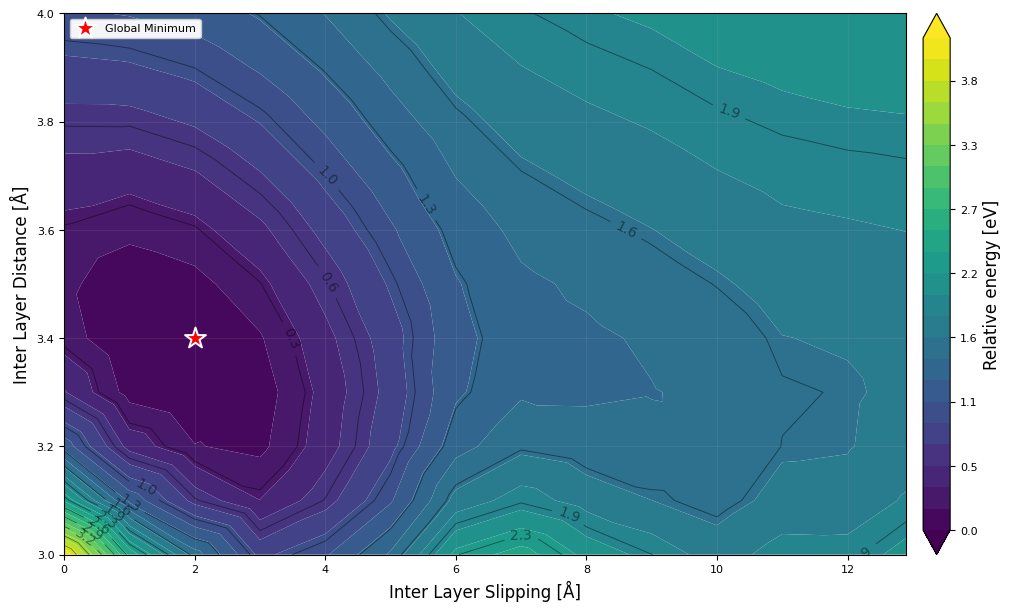

Saved: COF-LZU-1/3_COF-LZU-1_landscape/pes_COF-LZU-1_serr.png


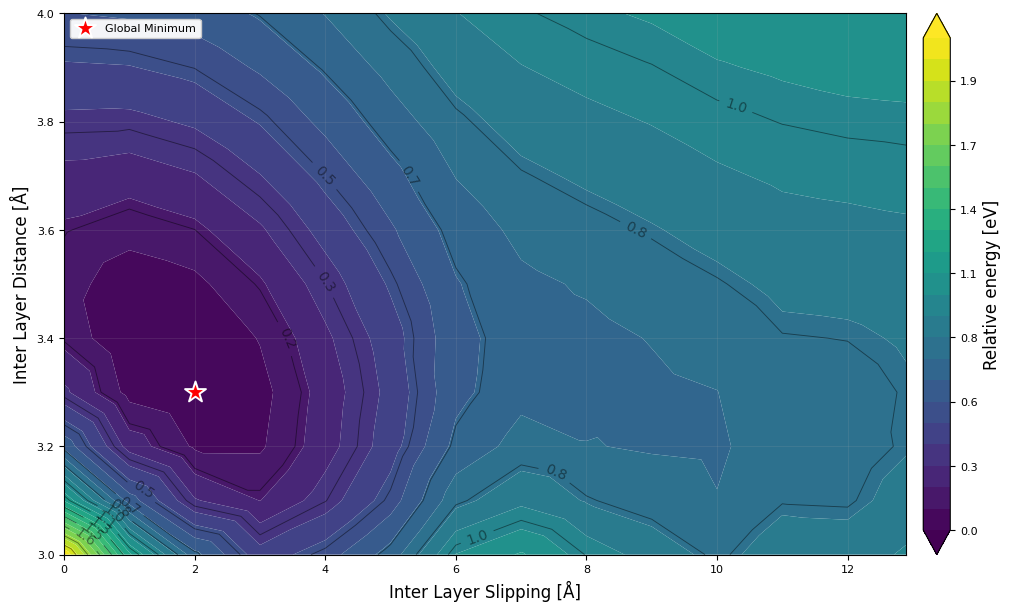

Saved: COF-LZU-1/3_COF-LZU-1_landscape/pes_COF-LZU-1_incl.png


In [5]:
landscape = cl.Landscape()
landscape.run(cof_name=COF_NAME, mode=MODE, show=True)

### Structure Selection for Optimization

This step selects candidate structures corresponding to automatically detected global or local minima and copies them into dedicated folders for subsequent geometry optimization.

By default, the global minimum of each stacking mode is selected automatically. Local minima can instead be selected by setting the corresponding minima option.

Additional sampling points identified from inspection of the simplified PES can also be included by providing `(ILD, ILS)` pairs separately for the serrated and inclined stacking modes, for example:

```python
EXTRA_SERR = [(3.4, 2.0), (3.5, 1.0)]
EXTRA_INCL = [(3.3, 2.0)]

In [6]:
EXTRA_SERR = []
EXTRA_INCL = []

In [7]:
selector = cl.SelectCofs()
selector.run(
    cof_name=COF_NAME,
    mode=MODE,
    selections_serr=EXTRA_SERR,
    selections_incl=EXTRA_INCL,
)


Selected ILD/ILS pairs (Serrated):
 ILD (Å)  ILS (Å)
     3.4      2.0

Selected ILD/ILS pairs (Inclined):
 ILD (Å)  ILS (Å)
     3.3      2.0


### MACE Geometry Optimization

This step performs geometry optimizations of selected stacking structures using `MaceOpt`.

`MaceOpt` uses ASE `FrechetCellFilter` + `LBFGS`, writes optimized CIF files, and can write a combined energy CSV (`{COF_NAME}_opt_energies_per_layer.csv`).

  Optimized structures (`.cif`) and optional energies CSV are written to:  
  `COF_NAME/4_{COF_NAME}_optimization/`

In [8]:
opt = cl.MaceOpt()
opt.run(cof_name=COF_NAME, mode=MODE)

       Step     Time          Energy          fmax
LBFGS:    0 20:46:47   -93390.171402        0.188833
LBFGS:    1 20:46:50   -93390.174004        0.118392
LBFGS:    2 20:46:52   -93390.175590        0.039153
LBFGS:    3 20:46:54   -93390.176325        0.039531
LBFGS:    4 20:46:56   -93390.177157        0.045275
LBFGS:    5 20:46:58   -93390.177876        0.038819
LBFGS:    6 20:47:00   -93390.178519        0.039127
LBFGS:    7 20:47:02   -93390.179077        0.037521
LBFGS:    8 20:47:04   -93390.179643        0.034101
LBFGS:    9 20:47:06   -93390.180283        0.032151
LBFGS:   10 20:47:08   -93390.181080        0.042614
LBFGS:   11 20:47:09   -93390.182129        0.049399
LBFGS:   12 20:47:11   -93390.183515        0.060603
LBFGS:   13 20:47:13   -93390.185050        0.069311
LBFGS:   14 20:47:15   -93390.186312        0.042314
LBFGS:   15 20:47:16   -93390.187250        0.033499
LBFGS:   16 20:47:18   -93390.188027        0.040056
LBFGS:   17 20:47:20   -93390.188835        0.04

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 7.516680880419728e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    1 20:50:22   -46695.103265        0.141562


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 7.567727473088132e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    2 20:50:23   -46695.106943        0.120082


...

LBFGS:  251 20:54:29   -46695.268008        0.015232


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 7.674905667086064e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:  252 20:54:29   -46695.268073        0.018213


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 7.727030660206788e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:  253 20:54:30   -46695.268127        0.009897
Saved optimized energies: COF-LZU-1/4_COF-LZU-1_optimization/COF-LZU-1_opt_energies_per_layer.csv


### Analysis & Visualization

This step analyzes optimized structures by computing interlayer distance (ILD) and interlayer slipping (ILS) from the optimized structures, and writing a summary CSV for comparison across stacking configurations.

In addition, structures can be visualized using an interactive viewer.

In [9]:
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE)

Serrated:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.4      1.5        0.1
Inclined:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.2      1.9        0.0


In [13]:
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(cof_name=COF_NAME, mode=MODE)

Serrated | COF-LZU-1_z34_L020_serr.cif: ILD = 3.36 Å, ILS = 1.51 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Inclined | COF-LZU-1_z33_L020_incl.cif: ILD = 3.25 Å, ILS = 1.86 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[<py3Dmol.view at 0x179067080>, <py3Dmol.view at 0x1786189b0>]

### PXRD simulation

Simulate PXRD patterns from the optimized structures. The simulated `.xy` patterns are written to the analysis-stage `pxrd_xy` folders.

In [14]:
pxrd = cl.PXRD(wavelength="CuKa", two_theta_range=(1.5, 30.0))
pxrd.run(cof_name=COF_NAME, mode=MODE)

{'serr': 'COF-LZU-1/5_COF-LZU-1_analysis/pxrd_xy/serr',
 'incl': 'COF-LZU-1/5_COF-LZU-1_analysis/pxrd_xy/incl'}

#### Simulated peak tables

Extract simulated reflections (100 by default) per structure . The resulting peak lists are saved as `<structure>_all.csv` in the mode-specific `pxrd_peaks` folders.

In [15]:
pxrd.extract_peaks(cof_name=COF_NAME, mode=MODE)

{'serr':                   structure  rank  two_theta_deg  relative_intensity
 0   COF-LZU-1_z34_L020_serr     1        4.56974             100.000
 1   COF-LZU-1_z34_L020_serr     2        4.56179              97.979
 2   COF-LZU-1_z34_L020_serr     3        4.56348              94.140
 3   COF-LZU-1_z34_L020_serr     4        9.14677              11.247
 4   COF-LZU-1_z34_L020_serr     5        9.13082              10.383
 5   COF-LZU-1_z34_L020_serr     6       26.52295              10.355
 6   COF-LZU-1_z34_L020_serr     7        9.13422               8.835
 7   COF-LZU-1_z34_L020_serr     8        7.91365               8.564
 8   COF-LZU-1_z34_L020_serr     9        7.91659               7.734
 9   COF-LZU-1_z34_L020_serr    10        7.90279               7.112
 10  COF-LZU-1_z34_L020_serr    11       12.09636               3.807
 11  COF-LZU-1_z34_L020_serr    12       12.10542               3.663
 12  COF-LZU-1_z34_L020_serr    13       12.10863               3.371
 13  COF-LZU

### Experimental comparison

Place exactly one experimental `.xy` file in `experimental_pxrd/`, or pass its path explicitly. The comparison generates one PDF per simulated structure in `pxrd_plots`.

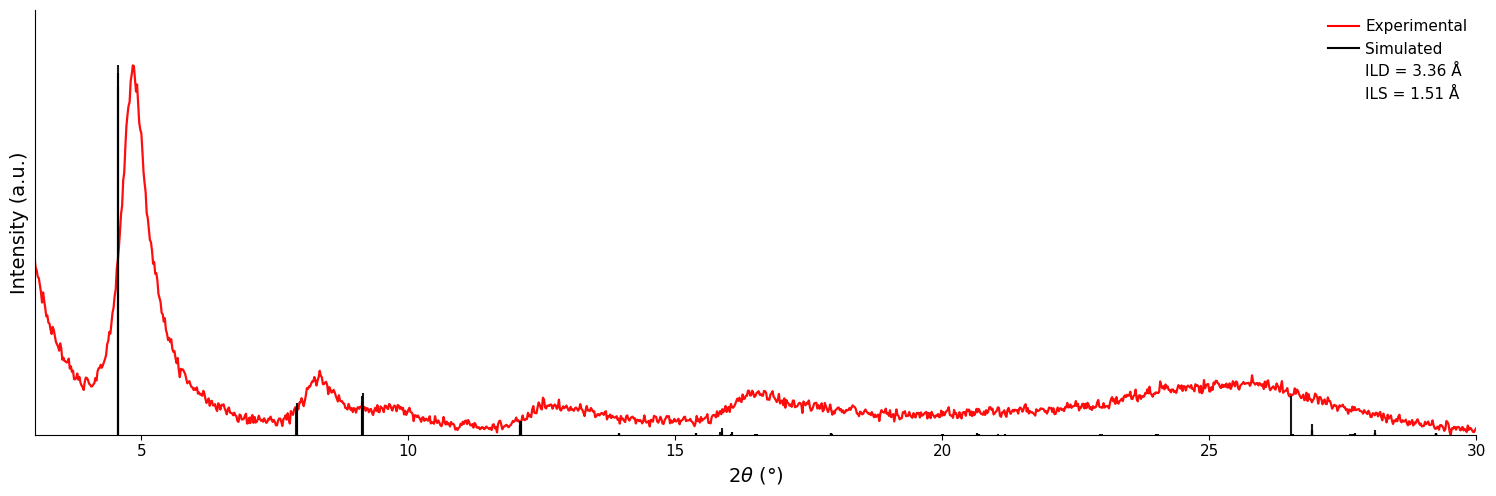

Plotted simulated and experimental PXRD pattern for COF-LZU-1_z34_L020_serr.cif


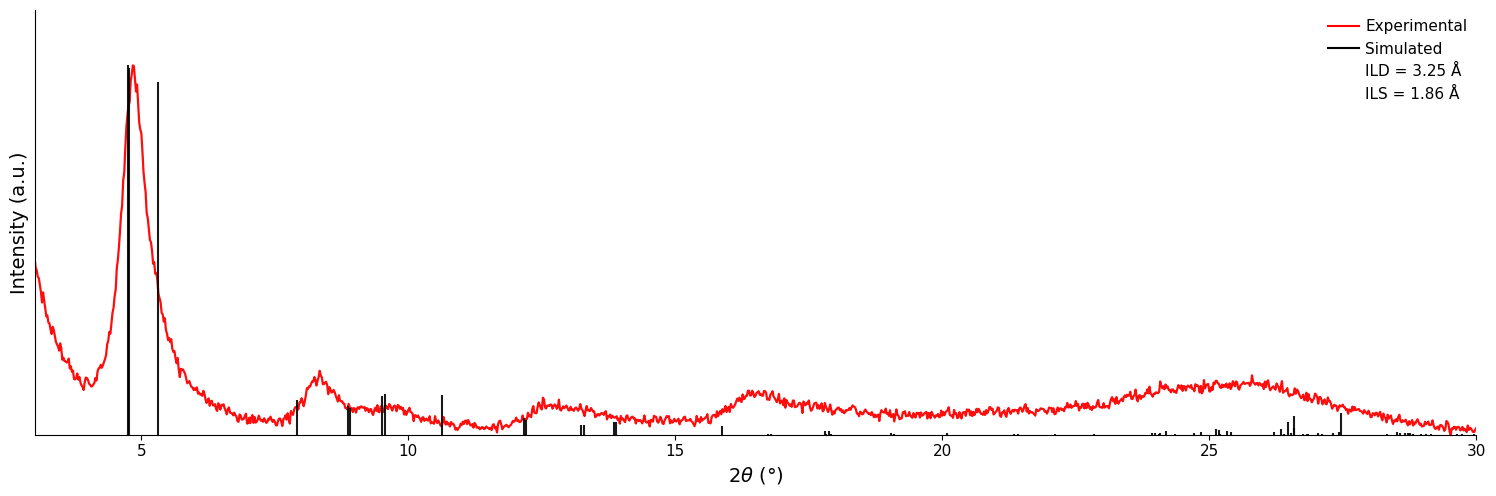

Plotted simulated and experimental PXRD pattern for COF-LZU-1_z33_L020_incl.cif


['COF-LZU-1/5_COF-LZU-1_analysis/pxrd_plots/serr/COF-LZU-1_z34_L020_serr.pdf',
 'COF-LZU-1/5_COF-LZU-1_analysis/pxrd_plots/incl/COF-LZU-1_z33_L020_incl.pdf']

In [16]:
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    xlim=(3, 30),
)

## PXRD-guided refinement

The simulated and experimental PXRD patterns should first be inspected qualitatively. The refinement described below is intended for structures that already reproduce the experimental pattern reasonably well but show a **systematic offset in peak positions**. It is not intended to correct a stacking model whose simulated PXRD pattern is fundamentally inconsistent with experiment.

A consistent displacement of corresponding simulated and experimental reflections can indicate that the predicted structure is qualitatively correct while its unit-cell dimensions differ slightly from those of the experimental material. COF-Landscaper therefore provides a simple PXRD-guided refinement in which experimental diffraction peak positions are used to adjust the in-plane dimensions of the calculated structure. This follows the general principle of refining lattice dimensions against diffraction data.

If both serrated and inclined structures were evaluated above, first select the stacking mode(s) that provides the physically meaningful agreement with experiment. The comparison is performed within **user-defined 2θ regions**. Each region should contain an experimental feature and the corresponding simulated reflection that the user intends to compare.

A region is specified by its lower and upper 2θ limits:
Example:
```python

peak_regions = [
    (4.0, 5.5),
    (7.5, 9.0),
    (9.0, 10.5),
]

In [17]:
MODE = "serr"

In [18]:
peak_regions = [
    (4.0, 5.5),
    (7.5, 9),
    (9, 10.5),
    (12, 14),
    (15.5, 17.5),
    (24, 27.5),
]

pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
)

{'COF-LZU-1_z34_L020_serr':     region  region_min  region_max source  two_theta  intensity  \
 0        1         4.0         5.5    exp   4.853669        NaN   
 1        1         4.0         5.5    sim   4.561790     97.979   
 2        1         4.0         5.5    sim   4.563480     94.140   
 3        1         4.0         5.5    sim   4.569740    100.000   
 4        2         7.5         9.0    exp   8.315781        NaN   
 5        2         7.5         9.0    sim   7.902790      7.112   
 6        2         7.5         9.0    sim   7.913650      8.564   
 7        2         7.5         9.0    sim   7.916590      7.734   
 8        3         9.0        10.5    exp   9.776081        NaN   
 9        3         9.0        10.5    sim   9.130820     10.383   
 10       3         9.0        10.5    sim   9.134220      8.835   
 11       3         9.0        10.5    sim   9.146770     11.247   
 12       4        12.0        14.0    exp  12.581022        NaN   
 13       4        12

### In-plane lattice scaling

The extracted experimental and simulated peak positions are used to estimate the in-plane lattice correction required to improve their agreement.

By default, all extracted peak regions are included (`scale_regions=None`). If some experimental features are broad, overlapping, or otherwise unsuitable for a reliable comparison, `scale_regions` can be used to restrict the scaling to selected regions.

For example, to use only regions 1, 2, and 4:

```python
scale_regions = [1, 2, 4]

In [19]:
scaled_cifs = pxrd.generate_scaled_cif(
    cof_name=COF_NAME,
    mode=MODE,
    scale_regions=[1,2],
)

### Post-optimization

The PXRD-guided scaling changes the unit-cell dimensions geometrically. The scaled structure is therefore subsequently re-optimized with MACE while keeping the refined unit cell fixed, allowing the atomic coordinates to relax within the experimentally informed cell.

In [20]:
postopt = cl.MaceOpt()
postopt.run_fixed(cof_name=COF_NAME, mode=MODE)

       Step     Time          Energy          fmax
LBFGS:    0 21:10:52   -93370.669833        4.715132
LBFGS:    1 21:10:54   -93375.980771        5.072262
LBFGS:    2 21:10:56   -93381.835846        1.643557
LBFGS:    3 21:10:58   -93382.683521        0.868263
LBFGS:    4 21:11:00   -93383.036579        0.758681
LBFGS:    5 21:11:03   -93383.191552        0.485614
LBFGS:    6 21:11:05   -93383.268659        0.297992
LBFGS:    7 21:11:08   -93383.327719        0.408955
LBFGS:    8 21:11:10   -93383.365298        0.385310
LBFGS:    9 21:11:12   -93383.391076        0.155663
LBFGS:   10 21:11:14   -93383.417576        0.283992
LBFGS:   11 21:11:17   -93383.453586        0.351876
LBFGS:   12 21:11:18   -93383.483093        0.371016
LBFGS:   13 21:11:20   -93383.503713        0.283407
LBFGS:   14 21:11:22   -93383.521748        0.194298
LBFGS:   15 21:11:24   -93383.545736        0.205664
LBFGS:   16 21:11:26   -93383.576867        0.376212
LBFGS:   17 21:11:28   -93383.606297        0.19

{'serr/COF-LZU-1_z34_L020_serr_0.9460': True}

## Postopt analysis

Repeat structural and PXRD analysis against the post-optimized structures using `source="postopt"`.

In [21]:
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE, source="postopt")

Serrated:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.4      1.4         --


In [22]:
pxrd.run(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peaks(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
    source="postopt",
)

{'COF-LZU-1_z34_L020_serr_0.9460':     region  region_min  region_max source  two_theta  intensity  \
 0        1         4.0         5.5    exp   4.853669        NaN   
 1        1         4.0         5.5    sim   4.822310     97.843   
 2        1         4.0         5.5    sim   4.824100     94.306   
 3        1         4.0         5.5    sim   4.830710    100.000   
 4        2         7.5         9.0    exp   8.315781        NaN   
 5        2         7.5         9.0    sim   8.354630      6.721   
 6        2         7.5         9.0    sim   8.366110      8.123   
 7        2         7.5         9.0    sim   8.369220      7.395   
 8        3         9.0        10.5    exp   9.776081        NaN   
 9        3         9.0        10.5    sim   9.653180      9.710   
 10       3         9.0        10.5    sim   9.656770      8.300   
 11       3         9.0        10.5    sim   9.670040     10.532   
 12       4        12.0        14.0    exp  12.581022        NaN   
 13       4   

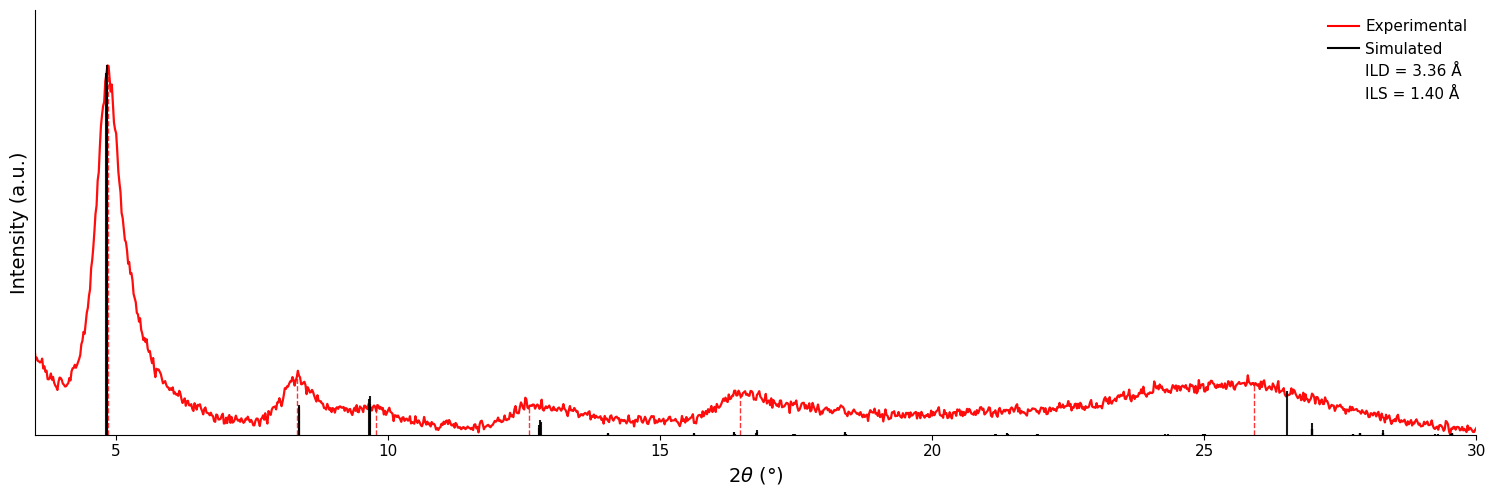

Plotted simulated and experimental PXRD pattern for COF-LZU-1_z34_L020_serr_0.9460.cif


['COF-LZU-1/7_COF-LZU-1_postanalysis/pxrd_plots/serr/COF-LZU-1_z34_L020_serr_0.9460.pdf']

In [23]:
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
    xlim=(3.5, 30.0),
)

In [24]:
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
)

Serrated | COF-LZU-1_z34_L020_serr_0.9460.cif: ILD = 3.36 Å, ILS = 1.40 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.